In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
combo_counts = df.groupby(['Store', 'Dept']).size().reset_index(name='count')
combo_counts.sort_values(by='count', ascending=False).head()

,Store,Dept,count
3329,45,97,143
0,1,1,143
3312,45,74,143
3311,45,72,143
3310,45,71,143


In [5]:
store_id = 45
dept_id = 97

ts = df[(df['Store'] == store_id) & (df['Dept'] == dept_id)]

ts = ts.sort_values(by='Date')
ts = ts[['Date', 'Weekly_Sales']]
ts.set_index('Date', inplace=True)

ts.head()

,Weekly_Sales
Date,
2010-02-05,8393.22
2010-02-12,5011.36
2010-02-19,5703.42
2010-02-26,6343.60
2010-03-05,5445.80


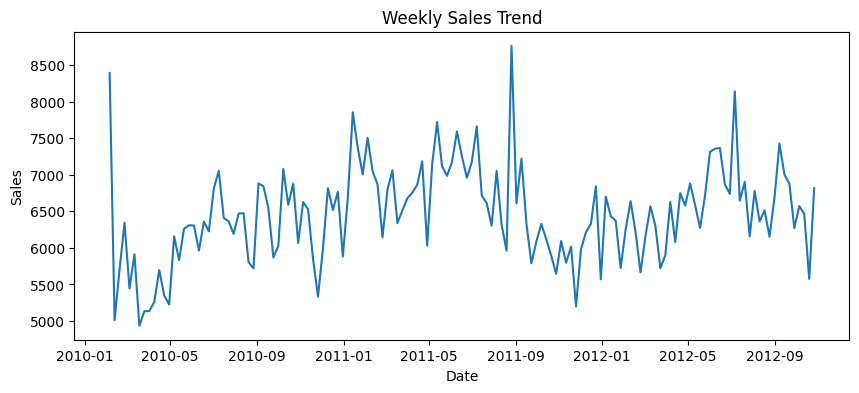

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(ts.index, ts['Weekly_Sales'])
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Sales Trend Observations

The sales data shows frequent fluctuations with multiple sharp spikes, indicating irregular demand patterns. There is no clear long-term trend, but repeated variations suggest the presence of seasonal or periodic effects.

In [7]:
last_value = ts['Weekly_Sales'].iloc[-1]

naive_forecast = [last_value] * 4
naive_forecast

[np.float64(6817.48),
 np.float64(6817.48),
 np.float64(6817.48),
 np.float64(6817.48)]

In [8]:
rolling_avg = ts['Weekly_Sales'].rolling(window=4).mean().iloc[-1]

rolling_forecast = [rolling_avg] * 4
rolling_forecast

[np.float64(6357.47),
 np.float64(6357.47),
 np.float64(6357.47),
 np.float64(6357.47)]

In [9]:
%pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 4.2 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(ts['Weekly_Sales'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

sarima_forecast = model_fit.forecast(steps=4)
sarima_forecast

c:\Users\Dell\Desktop\kachra\Rudder Assignments\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\Desktop\kachra\Rudder Assignments\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\Desktop\kachra\Rudder Assignments\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2012-11-02    6259.389320
2012-11-09    6621.019052
2012-11-16    6565.754697
2012-11-23    6657.903914
Freq: W-FRI, Name: predicted_mean, dtype: float64

# Sales Observations

- The time series shows frequent fluctuations with occasional spikes, indicating irregular demand patterns rather than a steady trend.
- Sales appear to exhibit seasonal behavior, with repeated increases and decreases over time rather than a consistent upward or downward movement.
- The SARIMA forecast produces varying values compared to naive and rolling forecasts, suggesting that the model captures underlying patterns such as seasonality and short-term variations.

In [11]:
future_dates = pd.date_range(start=ts.index[-1], periods=5, freq='W')[1:]

pred_df = pd.DataFrame({
    'Date': future_dates,
    'Naive': naive_forecast,
    'Rolling': rolling_forecast,
    'SARIMA': sarima_forecast.values
})

pred_df.to_csv("sales_forecast.csv", index=False)
pred_df

,Date,Naive,Rolling,SARIMA
0,2012-11-04,6817.48,6357.47,6259.389320
1,2012-11-11,6817.48,6357.47,6621.019052
2,2012-11-18,6817.48,6357.47,6565.754697
3,2012-11-25,6817.48,6357.47,6657.903914
